# Recommendation systems

In [37]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

## Carga de datos

In [38]:
with open('../../data/processed/recommendation-X-train.pkl', 'rb') as file:
    X_train = pickle.load(file)

with open('../../data/processed/recommendation-X-test.pkl', 'rb') as file:
    X_test = pickle.load(file)

with open('../../data/processed/recommendation-y-train.pkl', 'rb') as file:
    y_train = pickle.load(file)

with open('../../data/processed/recommendation-y-test.pkl', 'rb') as file:
    y_test = pickle.load(file)

## Modelado Predictivo

In [39]:
model = RandomForestClassifier(random_state = 25)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:

y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 1, 1], shape=(6033,))

In [41]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8435272666998177

In [42]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4529
           1       0.71      0.63      0.67      1504

    accuracy                           0.84      6033
   macro avg       0.80      0.77      0.78      6033
weighted avg       0.84      0.84      0.84      6033



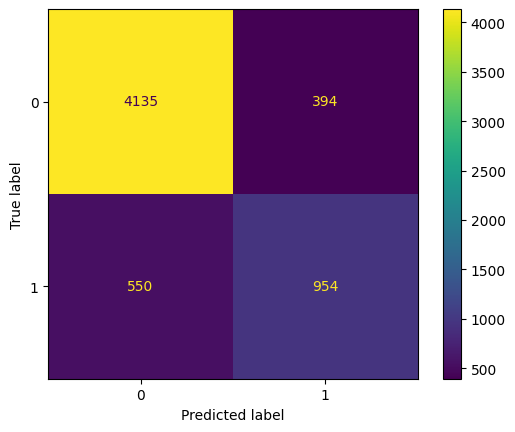

In [43]:
confusion = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion).plot()
plt.show()

>El modelo parece mostrar un accuracy de superior al 0.84, lo que es considerablemente alto, con el classification_report y la matriz de confusión podemos ver también que predice mejor los resultados de menos de 50K que los de más, aunque tenga una buena predicción en general.

## Optimización del modelo

In [44]:
hyperparams = {
    "n_estimators": [100, 200, 300],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

In [45]:
grid = RandomizedSearchCV(model, hyperparams, scoring = "accuracy", cv = 10)
grid

,estimator,RandomForestC...ndom_state=25)
,param_distributions,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy', ...], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [46]:
grid.fit(X_train, y_train)
grid.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': None,
 'max_depth': 20,
 'criterion': 'gini',
 'class_weight': None}

In [47]:
best = grid.best_estimator_
y_pred_best = best.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
accuracy, accuracy_best 

(0.8435272666998177, 0.8577821979114868)

In [48]:
grid_report = classification_report(y_test, y_pred_best)
print(report, grid_report)

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4529
           1       0.71      0.63      0.67      1504

    accuracy                           0.84      6033
   macro avg       0.80      0.77      0.78      6033
weighted avg       0.84      0.84      0.84      6033
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      4529
           1       0.75      0.64      0.69      1504

    accuracy                           0.86      6033
   macro avg       0.82      0.79      0.80      6033
weighted avg       0.85      0.86      0.85      6033



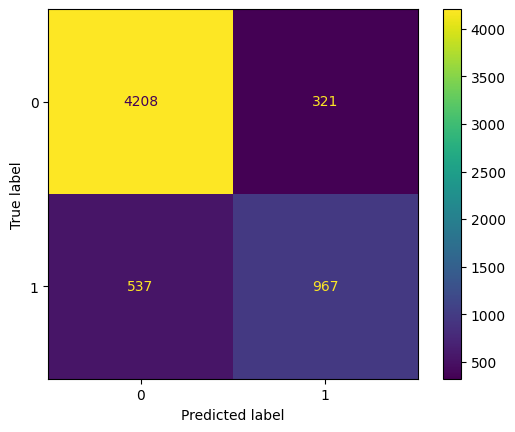

In [49]:
confusion_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_best).plot()
plt.show()

>En la optimización del modelo vemos que hay una mejora leve en el accuracy general, pero vemos también que esta mejora se centra en los casos donde la gente ingresa menos de 50K empeorando en la precisión de la decisión de más de 50K en ingresos, pasamos de un accuracy 0.844 a 0.850 (valores truncados), que es una mejora muy leve y dado el empeoramiento mencionado nos quedaremos con el original.

## Definición del segundo problema

>Tenemos que predecir que categorías de las que tenemos en el dataframe se podrían mejorar para pasar de ingresar menos de 50K o más.

## Análisis de importancia de variables 

>Vamos a ver primero de todo las importancias de cada caracteristica para el modelo optimizado y básico.

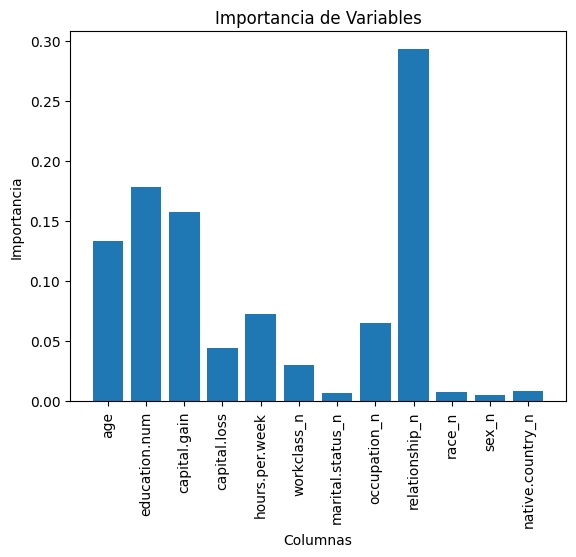

In [50]:
plt.bar(X_train.columns, best.feature_importances_)
plt.xticks(rotation=90)
plt.ylabel('Importancia')
plt.xlabel('Columnas')
plt.title("Importancia de Variables")
plt.show()

>Vemos que las variables que más parecen afectar al resultado son las relaciones, la edad, la educación, las ganancias de capital, las horas de trabajo por semana y el trabajo, también con leve importancia le siguen la clase laboral, las perdidas de capital, el estado marital, la raza, el país de nacimiento y el sexo, en ese orden todo esto.

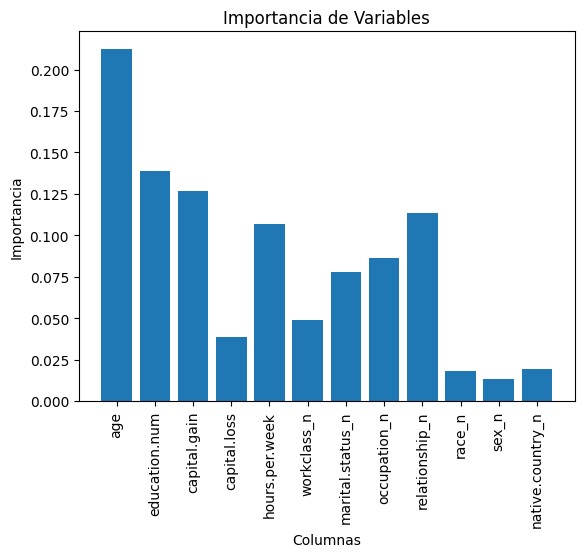

In [51]:
plt.bar(X_train.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.ylabel('Importancia')
plt.xlabel('Columnas')
plt.title("Importancia de Variables")
plt.show()

>En el modelo sin optimizar vemos que de las variables que a priori se pueden cambiar tienen el mismo orden aunque en general se vean cambios, estas variables que considero que se pueden cambiar por orden de importancia para los dos modelos son education.num, hours.per.week, occupation_n y workclass_n.

## Sistema de recomendación


>Vamos a aplicar un modelo KNN para ver en que grupos podemos agrupar a los elementos estudiados para ver que les recomendamos si no llegan a 50K

>Para empezar vamos a entrenar el Nearest Neighbours con solo los valores que tienen más de 50K en ingresos. Para ello también trataremos los datos de X_train y y_train.

In [52]:
Xy_train = X_train.copy()
Xy_train['income_n'] = y_train
high_earners = Xy_train[Xy_train['income_n'] == 1]
high_earners.drop(columns=['income_n'], inplace=True)
knn_model = NearestNeighbors()
knn_model.fit(high_earners)

/tmp/ipykernel_755/2427338653.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_earners.drop(columns=['income_n'], inplace=True)


,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


>Probaremos como funciona viendo los vecinos cercanos a un valor con menos de 50K en ingresos

In [53]:
y_test.iloc[4528]

np.int64(0)

>Aquí comprobamos que ese valor tiene en el dataframe original menos de 50K en ingresos y después visualizamos sus datos

In [54]:
test = pd.DataFrame(X_test.iloc[4528]).T
test

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_n,marital.status_n,occupation_n,relationship_n,race_n,sex_n,native.country_n
19016,0.473684,-1.25,0.0,0.0,0.0,0.0,0.0,0.0,1.333333,0.0,-1.0,-1.0


>Vemos también sus 5 vecinos más cercanos que si que ingresan más de 50K mediante el modelo

In [55]:
knn_model.kneighbors(test)


(array([[1.42979765, 1.46141509, 1.47556271, 1.47772578, 1.47866276]]),
 array([[1604, 3237, 4669, 2354,  946]]))

In [56]:
index = knn_model.kneighbors(test)[1][0]
index

array([1604, 3237, 4669, 2354,  946])

>Vemos también lo que dice el modelo que usaremos de los vecinos estudiados y vemos que casi todos los da como gente que ingresa más de 50K

In [57]:
model.predict(pd.DataFrame(high_earners.iloc[index]))

array([0, 1, 1, 1, 1])

In [58]:
vecinos = high_earners.iloc[index]
pd.concat([vecinos, test])


,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_n,marital.status_n,occupation_n,relationship_n,race_n,sex_n,native.country_n
26803,0.263158,-0.25,0.0,0.0,0.0,0.0,0.0,0.000000,1.333333,0.0,-1.0,0.0
6993,0.105263,-0.25,0.0,0.0,0.0,0.0,0.0,0.000000,1.333333,0.0,-1.0,0.0
23685,0.894737,-0.25,0.0,0.0,0.0,0.0,0.0,0.000000,1.333333,0.0,-1.0,0.0
17765,0.473684,-0.25,0.0,0.0,0.0,0.0,0.0,-0.428571,1.333333,0.0,-1.0,0.0
10037,0.526316,-0.25,0.0,0.0,0.0,0.0,0.0,-0.428571,1.333333,0.0,-1.0,0.0
19016,0.473684,-1.25,0.0,0.0,0.0,0.0,0.0,0.000000,1.333333,0.0,-1.0,-1.0


>Vemos que la mayor diferencia entre los que si ingresan 50K cercanos al test y el propio test que no ingresa más de 50K es el país de nacimiento y la educación ya que el resto de valores son identicos escepto la edad que es muy variable y quizá la ocupación que está más repartida con 2 diferentes y 3 iguales entre los 5 vecinos más cercanos.

>En este caso le recomendariamos principalmente mejorar su educación y quizá secundariamente cambiar su ocupación. Ahora vamos a buscar hacerlo de manera algorítmica y automatica.


In [59]:
variables_cambio = ['education.num', 'hours.per.week', 'occupation_n', 'workclass_n']
variables_dict = {'education.num' : 'formación',
                  'hours.per.week' : 'cantidad semanal de horas trabajadas',
                  'occupation_n' : 'trabajo',
                  'workclass_n' : 'clase laboral'}
nuevo_registro = test

def modelo_predictivo(user, pred_model, recommendation_model):
    pred = pred_model.predict(user)[0]
    recomendaciones = []
    if pred == 1:
        recomendaciones.append("Este perfil ya se predice con ingresos >50K. No se requieren recomendaciones.")
    else:
        indice_vecinos = recommendation_model.kneighbors(user)[1][0]
        vecinos = high_earners.iloc[indice_vecinos]
        for variable in variables_cambio:
            moda_vecinos = vecinos[variable].mode()[0]
            valor_actual = user[variable].values[0]
            if valor_actual != moda_vecinos:
                recomendaciones.append(f"Considerar cambiar tu {variables_dict[variable]}")

    return recomendaciones

modelo_predictivo(test, model, knn_model)

['Considerar cambiar tu formación']

## Prueba con ejemplos inventados

>Creamos 3 ejemplos con los que pondremos a prueba tanto el modelo predictivo como el sistema de recomendación

In [60]:
usuarios_prueba = {'usuario_1' : {'age' : 24, 
                                'education.num' : 10, 
                                'capital.gain' : 0, 
                                'capital.loss' : 0,
                                'hours.per.week' : 15, 
                                'workclass' : 'Private', 
                                'marital.status' : 'Never-married',
                                'occupation' : 'Prof-specialty', 
                                'relationship' : 'Unmarried', 
                                'race' : 'Other',
                                'sex' : 'Male', 
                                'native.country' : 'France'},
                   'usuario_2' : {'age' : 24, 
                                'education.num' : 15, 
                                'capital.gain' : 0, 
                                'capital.loss' : 0,
                                'hours.per.week' : 15, 
                                'workclass' : 'Private', 
                                'marital.status' : 'Never-married',
                                'occupation' : 'Prof-specialty', 
                                'relationship' : 'Unmarried', 
                                'race' : 'Other',
                                'sex' : 'Male', 
                                'native.country' : 'France'},
                   'usuario_3' : {'age' : 30, 
                                'education.num' : 10, 
                                'capital.gain' : 0, 
                                'capital.loss' : 0,
                                'hours.per.week' : 30, 
                                'workclass' : 'Private', 
                                'marital.status' : 'Married-civ-spouse',
                                'occupation' : 'Tech-support', 
                                'relationship' : 'Husband', 
                                'race' : 'Other',
                                'sex' : 'Male', 
                                'native.country' : 'France'} 
}

ejemplos = pd.DataFrame(usuarios_prueba).T.reset_index(drop=True)
ejemplos

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass,marital.status,occupation,relationship,race,sex,native.country
0,24,10,0,0,15,Private,Never-married,Prof-specialty,Unmarried,Other,Male,France
1,24,15,0,0,15,Private,Never-married,Prof-specialty,Unmarried,Other,Male,France
2,30,10,0,0,30,Private,Married-civ-spouse,Tech-support,Husband,Other,Male,France


In [61]:
label_categories = ['workclass', 'marital.status', 'occupation',
                    'relationship', 'race', 'sex', 'native.country']

label_encoders = {}

for column in label_categories:
    with open(f'../../models/recommendation-label-encoder-{column}.pkl', 'rb') as file:
        label_encoders[f'{column}'] = pickle.load(file)

with open('../../models/recommendation-robust-scaler.pkl', 'rb') as file:
    robust_scaler = pickle.load(file) 

label_encoders

{'workclass': LabelEncoder(),
 'marital.status': LabelEncoder(),
 'occupation': LabelEncoder(),
 'relationship': LabelEncoder(),
 'race': LabelEncoder(),
 'sex': LabelEncoder(),
 'native.country': LabelEncoder()}

In [62]:
for column in label_categories:
    ejemplos[f'{column}_n'] = label_encoders[column].transform(ejemplos[column])
    ejemplos.drop(f'{column}', axis=1, inplace=True)

robust_scaler_ejemplos = robust_scaler.transform(ejemplos)
ejemplos = pd.DataFrame(robust_scaler_ejemplos,
                       columns=ejemplos.columns,
                       index=ejemplos.index)

ejemplos

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_n,marital.status_n,occupation_n,relationship_n,race_n,sex_n,native.country_n
0,-0.684211,0.00,0.0,0.0,-5.0,0.0,1.0,0.428571,1.000000,-1.0,0.0,-28.0
1,-0.684211,1.25,0.0,0.0,-5.0,0.0,1.0,0.428571,1.000000,-1.0,0.0,-28.0
2,-0.368421,0.00,0.0,0.0,-2.0,0.0,0.0,0.857143,-0.333333,-1.0,0.0,-28.0


>Gracias a los Encoders y Scalers utilizados en el EDA puedo pasar a numéricas todas las variables y escalarlas para poder pasar por los modelos, para que me den recomendaciones respecto a cada uno de los ejemplos.

In [67]:
ejemplos.iloc[0]

age                 -0.684211
education.num        0.000000
capital.gain         0.000000
capital.loss         0.000000
hours.per.week      -5.000000
workclass_n          0.000000
marital.status_n     1.000000
occupation_n         0.428571
relationship_n       1.000000
race_n              -1.000000
sex_n                0.000000
native.country_n   -28.000000
Name: 0, dtype: float64

In [69]:
for i in range(len(ejemplos)):
    print(f'Las recomendaciones para el ejemplo número {i + 1} son:')
    print(modelo_predictivo(pd.DataFrame(ejemplos.iloc[i]).T, model, knn_model))

Las recomendaciones para el ejemplo número 1 son:
['Considerar cambiar tu trabajo']
Las recomendaciones para el ejemplo número 2 son:
['Considerar cambiar tu formación', 'Considerar cambiar tu trabajo']
Las recomendaciones para el ejemplo número 3 son:
['Considerar cambiar tu formación', 'Considerar cambiar tu cantidad semanal de horas trabajadas', 'Considerar cambiar tu trabajo']


>Aquí vemos como funciona el sistema de recomendación con los valores que hemos dado